### Heart Attack Prediction - Coursework 1

#### Problem Definition

Heart attacks are a serious condition and a life-threatening emergency. Artificial Intelligence can help predict heart attacks and save lives. 
We are looking for an AI-based model to predict the heart attack given some health indicators such as BMI, age, being a smoker, with high accuracy. <br>
Please write a report in 1500 words explaining in detail different stages of achieving the goal of this project. The report should include the following steps in detail. The dataset has been provided for you on Moodle. <br>
1.1 Prepare the dataset for training (Check for missing values, splitting the dataset in training and testing datasets…). <br>
1.2 Choose and tailor 4 Models you have learnt during lectures including an ANN-based model and train and build the models. <br>
1.3 Evaluate your model using metrics you have learnt during the lectures. <br>
1.4 Compare the models and report the most accurate model for this purpose. <br>
1.5 Please provide 2 ways (with evidence) to further improve the accuracy of your best model.

#### Project Goal

- To create a model that can predict whether someone will get a heart attack or not

Project sections:
1. Data ingestion, Data preprocessing, Data segragation
2. Model selection, Model training
3. Model evaluation (use all metrics) - recall is the most important
4. Compare selected models and report the most accurate model
5. Provide 2 ways (with evidence) to further improve the accuracy of the model selected in (4)

#### Importing Required Python Libraries

In [52]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn import preprocessing
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from collections import Counter
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report, precision_score, roc_auc_score, recall_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import precision_recall_curve

#### Section 1

##### 1.1 Data Ingestion

In [53]:
heart_data = pd.read_csv("heart_attack.csv")
heart_data.head()

,HeartDiseaseorAttack,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,Diabetes,PhysActivity,HvyAlcoholConsump,MentHlth,PhysHlth,Sex,Age,Education,Income
0,0,1,1,1,40.0,1,0,0,0,0,18,15,0,9,4,3
1,0,0,0,0,25.0,1,0,0,1,0,0,0,0,7,6,1
2,0,1,1,1,28.0,0,0,0,0,0,30,30,0,9,4,8
3,0,1,0,1,27.0,0,0,0,1,0,0,0,0,11,3,6
4,0,1,1,1,24.0,0,0,0,1,0,3,0,0,11,5,4


##### 1.2 Data Insights/Analysis

In [54]:
# Every feature is of integer type, so encoding is not necessary for this dataset
heart_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 129998 entries, 0 to 129997
Data columns (total 16 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   HeartDiseaseorAttack  129998 non-null  int64  
 1   HighBP                129998 non-null  int64  
 2   HighChol              129998 non-null  int64  
 3   CholCheck             129998 non-null  int64  
 4   BMI                   129988 non-null  float64
 5   Smoker                129998 non-null  int64  
 6   Stroke                129998 non-null  int64  
 7   Diabetes              129998 non-null  int64  
 8   PhysActivity          129998 non-null  int64  
 9   HvyAlcoholConsump     129998 non-null  int64  
 10  MentHlth              129998 non-null  int64  
 11  PhysHlth              129998 non-null  int64  
 12  Sex                   129998 non-null  int64  
 13  Age                   129998 non-null  int64  
 14  Education             129998 non-null  int64  
 15  

In [55]:
# statistical analysis of the data
heart_data.describe().T

,count,mean,std,min,25%,50%,75%,max
HeartDiseaseorAttack,129998.0,0.093509,0.291146,0.0,0.0,0.0,0.0,1.0
HighBP,129998.0,0.429614,0.495023,0.0,0.0,0.0,1.0,1.0
HighChol,129998.0,0.426322,0.494544,0.0,0.0,0.0,1.0,1.0
CholCheck,129998.0,0.963315,0.187988,0.0,1.0,1.0,1.0,1.0
BMI,129988.0,28.435586,6.999582,12.0,24.0,27.0,31.0,98.0
Smoker,129998.0,0.448030,0.497294,0.0,0.0,0.0,1.0,1.0
Stroke,129998.0,0.041354,0.199110,0.0,0.0,0.0,0.0,1.0
Diabetes,129998.0,0.296689,0.697608,0.0,0.0,0.0,0.0,2.0
PhysActivity,129998.0,0.760758,0.426622,0.0,1.0,1.0,1.0,1.0
HvyAlcoholConsump,129998.0,0.057562,0.232915,0.0,0.0,0.0,0.0,1.0


Points I noted from the stats above;
1. Only 9.35% of people had a heart attack according to the dataset, hence there's a bias towards people not getting heart attacks
2. 96% of people went for cholesterol check
3. The highest BMI value is 98, these are likely outliers and might be dropped
4. 76% of people are physically active
5. Only 5.7% of people are heavy alcohol consumers
6. The average age group of the dataset is between 60-64 (age group 8)
7. BMI, Diabetes, MentHlth, PhysHlth, Age, Education, and Income are not binary values

In [56]:
# checking for null values
heart_data.isnull().sum()

HeartDiseaseorAttack     0
HighBP                   0
HighChol                 0
CholCheck                0
BMI                     10
Smoker                   0
Stroke                   0
Diabetes                 0
PhysActivity             0
HvyAlcoholConsump        0
MentHlth                 0
PhysHlth                 0
Sex                      0
Age                      0
Education                0
Income                   0
dtype: int64

Points I noted from the null values output;
1. BMI has 10 null values

##### Visualizing Outcome Data Distribution
- As we identified from the dataset stats, only 9.35% of people had a heart attack according to the dataset, hence there's a bias towards people not getting heart attacks. Below is a visual representation of the same.

/var/folders/cj/x4b957m11wb_2wmjnhdlq2400000gn/T/ipykernel_37555/454446084.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sb.countplot(x=Y, data=heart_data, palette='Set2')


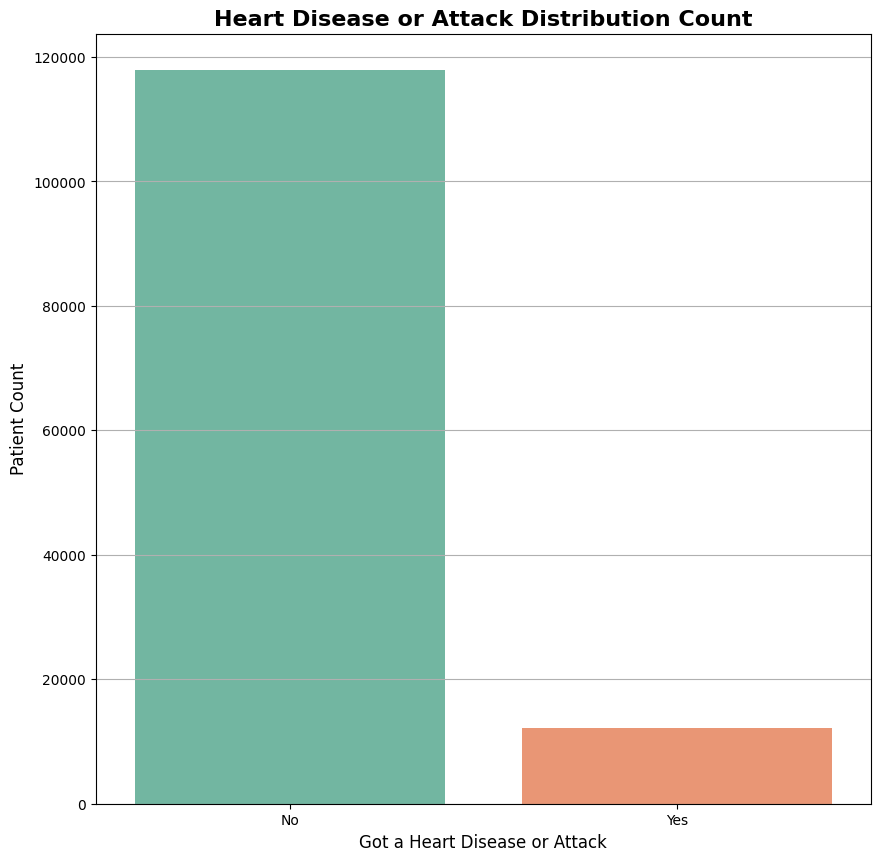

In [57]:
Y = heart_data['HeartDiseaseorAttack']
plt.figure(figsize=(10,10))
sb.countplot(x=Y, data=heart_data, palette='Set2')
plt.title("Heart Disease or Attack Distribution Count", fontweight="bold", fontsize=16)
plt.xlabel("Got a Heart Disease or Attack", fontsize=12)
plt.ylabel("Patient Count", fontsize=12)
plt.xticks([0, 1], ['No', 'Yes'])
plt.grid(visible=True, axis='y')
plt.show()



##### Visualizing Non-binary Numerical Data Distribution

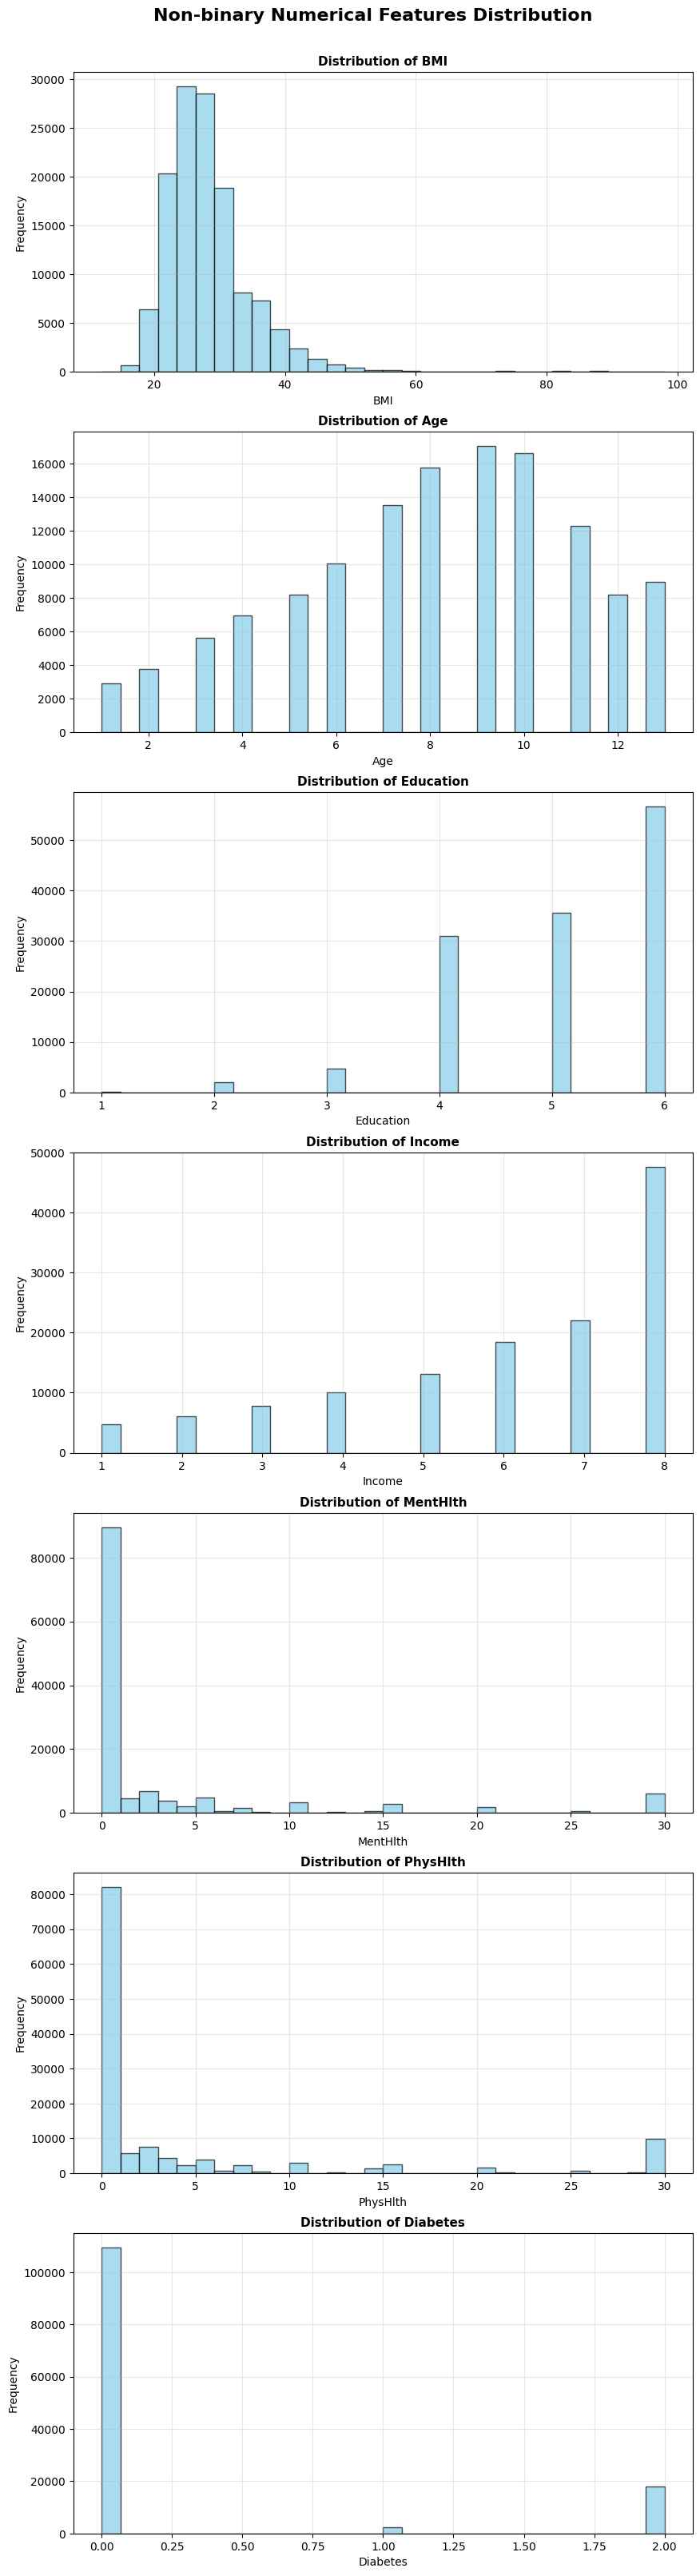

In [58]:
non_binary_numerical_columns = ['BMI','Age', 'Education', 'Income', 'MentHlth', 'PhysHlth', 'Diabetes' ]
n_columns = 1
n_rows = 7
figure, axes = plt.subplots(n_rows, n_columns, figsize=(10, 40))
axes = axes.flatten()

for x_axis, y_axis in enumerate(non_binary_numerical_columns):
    axes[x_axis].hist(heart_data[y_axis], bins=30, color='skyblue', edgecolor='black', alpha=0.7)
    axes[x_axis].set_title(f'Distribution of {y_axis}', fontsize=11, fontweight='bold')
    axes[x_axis].set_xlabel(y_axis, fontsize=10)
    axes[x_axis].set_ylabel('Frequency', fontsize=10)
    axes[x_axis].grid(True, alpha=0.3)

plt.suptitle("Non-binary Numerical Features Distribution", fontsize=16, fontweight="bold", y=0.9)
plt.show()


##### 1.2 Data Pre-processing

In [59]:
# checking for null values
data = {'Null Value Count': heart_data.isnull().sum()}
heart_data_null_values = pd.DataFrame(data)
heart_data_null_values.head(15)

,Null Value Count
HeartDiseaseorAttack,0
HighBP,0
HighChol,0
CholCheck,0
BMI,10
Smoker,0
Stroke,0
Diabetes,0
PhysActivity,0
HvyAlcoholConsump,0


Drop rows with null values

In [60]:
heart_data_dropped_nan = heart_data.dropna()
heart_data_dropped_nan.isnull().sum()

HeartDiseaseorAttack    0
HighBP                  0
HighChol                0
CholCheck               0
BMI                     0
Smoker                  0
Stroke                  0
Diabetes                0
PhysActivity            0
HvyAlcoholConsump       0
MentHlth                0
PhysHlth                0
Sex                     0
Age                     0
Education               0
Income                  0
dtype: int64

In [61]:
# checking for 0 value in ordinal features/columns
cols_no_zero_allowed = ["Age", "Education", "Income"]

for col in cols_no_zero_allowed:
    zero_count = (heart_data_dropped_nan[col] == 0).sum()
    print(f"{col}: {zero_count} zero values")

Age: 0 zero values
Education: 0 zero values
Income: 0 zero values


Feature correlation analysis

In [62]:

heart_data_correlation_matrix = heart_data_dropped_nan.drop('HeartDiseaseorAttack', axis=1).corr()
heart_data_correlation_matrix

,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,Diabetes,PhysActivity,HvyAlcoholConsump,MentHlth,PhysHlth,Sex,Age,Education,Income
HighBP,1.000000,0.297264,0.098667,0.203393,0.097617,0.128930,0.273298,-0.127643,-0.008999,0.055358,0.158593,0.047396,0.341526,-0.142332,-0.172278
HighChol,0.297264,1.000000,0.085881,0.098517,0.089150,0.090431,0.210785,-0.078146,-0.014512,0.060518,0.120949,0.029343,0.272947,-0.069054,-0.085526
CholCheck,0.098667,0.085881,1.000000,0.033625,-0.010924,0.024493,0.067325,0.005694,-0.022406,-0.009104,0.030472,-0.023645,0.089687,0.003558,0.017792
BMI,0.203393,0.098517,0.033625,1.000000,0.008881,0.018458,0.210638,-0.144283,-0.048076,0.083905,0.114756,0.040434,-0.042251,-0.099991,-0.100561
Smoker,0.097617,0.089150,-0.010924,0.008881,1.000000,0.061210,0.061023,-0.089105,0.100043,0.091191,0.117075,0.087966,0.125028,-0.166912,-0.131211
Stroke,0.128930,0.090431,0.024493,0.018458,0.061210,1.000000,0.106085,-0.070931,-0.017654,0.077616,0.153491,0.001878,0.126518,-0.078568,-0.132727
Diabetes,0.273298,0.210785,0.067325,0.210638,0.061023,0.106085,1.000000,-0.124229,-0.058051,0.077076,0.176675,0.026898,0.181623,-0.131728,-0.171710
PhysActivity,-0.127643,-0.078146,0.005694,-0.144283,-0.089105,-0.070931,-0.124229,1.000000,0.014490,-0.128765,-0.222807,0.031314,-0.093593,0.203518,0.197587
HvyAlcoholConsump,-0.008999,-0.014512,-0.022406,-0.048076,0.100043,-0.017654,-0.058051,0.014490,1.000000,0.022450,-0.027766,0.001878,-0.033917,0.023600,0.052878
MentHlth,0.055358,0.060518,-0.009104,0.083905,0.091191,0.077616,0.077076,-0.128765,0.022450,1.000000,0.357984,-0.081337,-0.093022,-0.107210,-0.215318


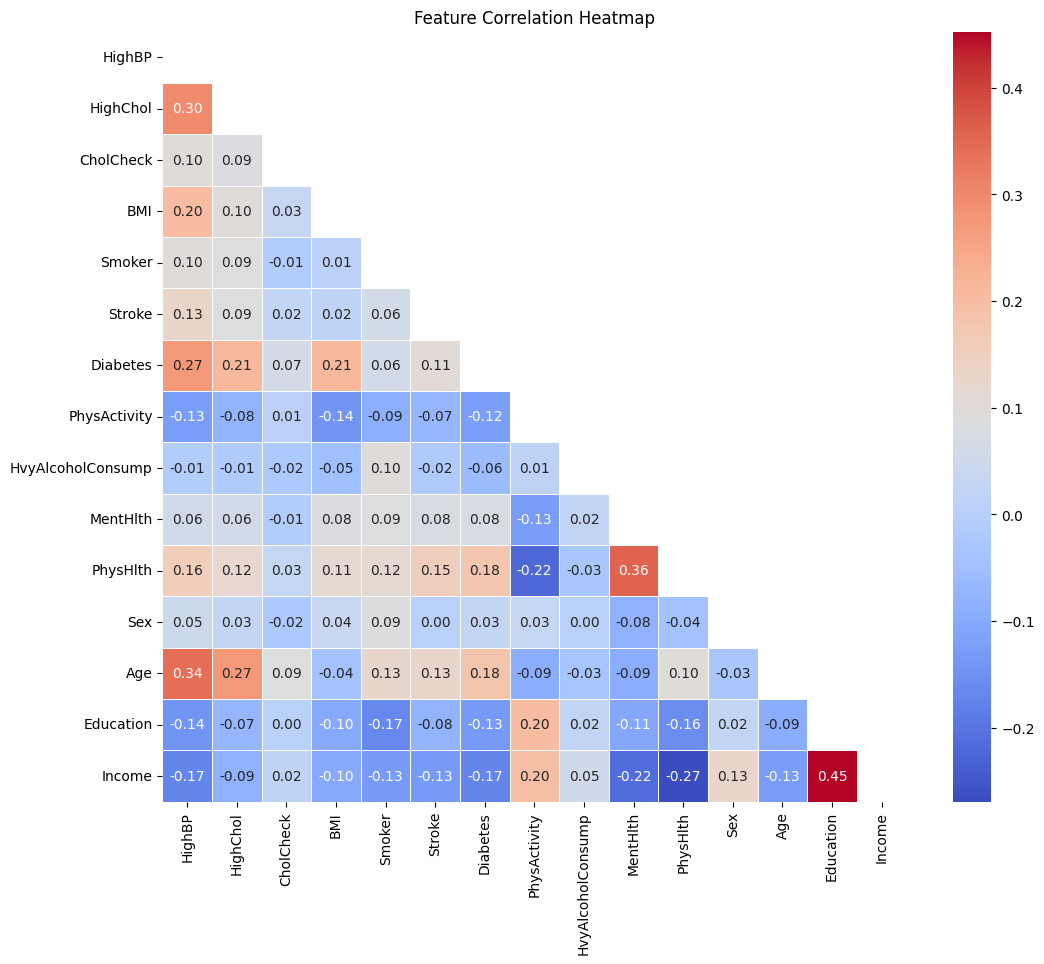

In [63]:
plt.figure(figsize=(12,10))

mask = np.triu(np.ones_like(heart_data_correlation_matrix, dtype=bool))

sb.heatmap(
    heart_data_correlation_matrix,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Feature Correlation Heatmap")
plt.show()

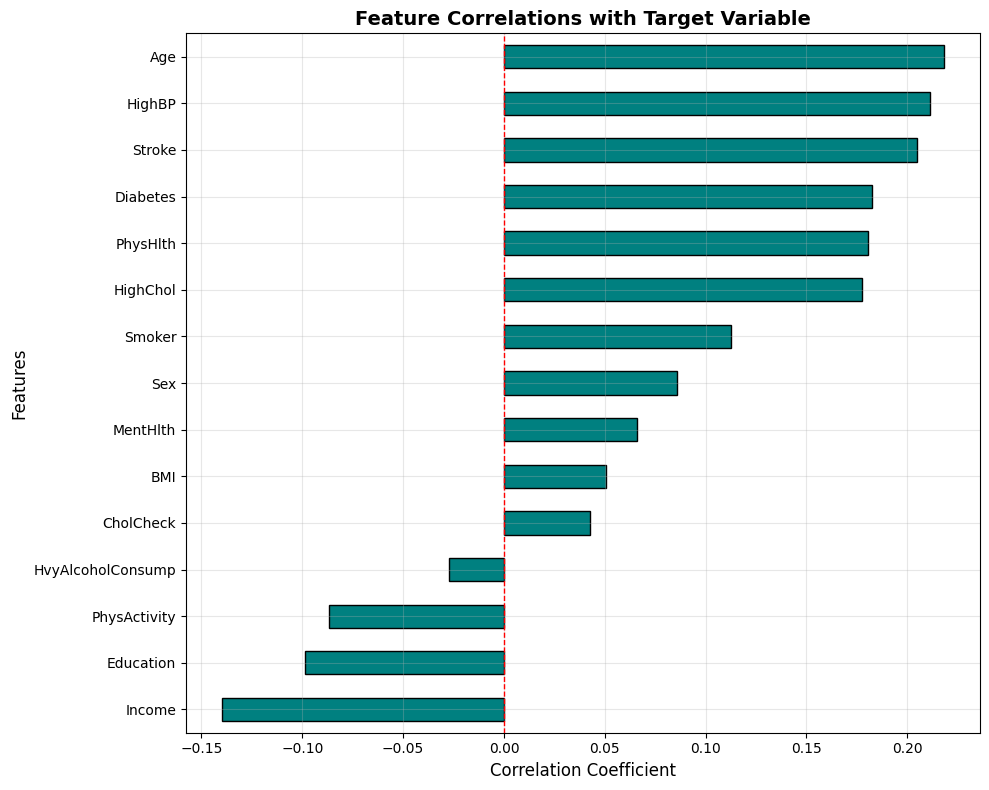

In [64]:
# Visualize top correlations with target
# compute correlations
corr_matrix = heart_data_dropped_nan.corr()

# get correlation with target
target_corr = corr_matrix['HeartDiseaseorAttack']

# drop the target itself
target_corr = target_corr.drop('HeartDiseaseorAttack')

# sort values
target_corr_sorted = target_corr.sort_values()

# plot
plt.figure(figsize=(10, 8))

target_corr_sorted.plot(
    kind='barh',
    color='teal',
    edgecolor='black'
)

plt.title('Feature Correlations with Target Variable', fontsize=14, fontweight='bold')
plt.xlabel('Correlation Coefficient', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.axvline(x=0, color='red', linestyle='--', linewidth=1)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

##### 1.3 Data Segregation

In [65]:
# separate features from target/outcome
X = heart_data_dropped_nan.drop('HeartDiseaseorAttack', axis=1)
print("======================================================================")
print(X)
print("======================================================================")
# assign target to y
y = heart_data_dropped_nan['HeartDiseaseorAttack']
print("======================================================================")
print(y)
print("======================================================================")

        HighBP  HighChol  CholCheck   BMI  Smoker  Stroke  Diabetes  \
0            1         1          1  40.0       1       0         0   
1            0         0          0  25.0       1       0         0   
2            1         1          1  28.0       0       0         0   
3            1         0          1  27.0       0       0         0   
4            1         1          1  24.0       0       0         0   
...        ...       ...        ...   ...     ...     ...       ...   
129993       1         1          1  25.0       1       0         0   
129994       0         0          1  27.0       0       0         0   
129995       0         0          1  29.0       0       0         0   
129996       0         0          0  21.0       0       0         0   
129997       0         0          1  21.0       1       0         0   

        PhysActivity  HvyAlcoholConsump  MentHlth  PhysHlth  Sex  Age  \
0                  0                  0        18        15    0    9   
1

In [66]:
# splitting the dataset into training and testing data. 
# since data is sufficient, I did a 70-30 split
X_train, X_test, Y_train, y_test = train_test_split(X,y, test_size=0.3, random_state=0)

print("X_train Shape:", X_train.shape)
print("X_test Shape: ", X_test.shape)
print("Y_train Shape: ", Y_train.shape)
print("y_test Shape: ", y_test.shape)

X_train Shape: (90991, 15)
X_test Shape:  (38997, 15)
Y_train Shape:  (90991,)
y_test Shape:  (38997,)


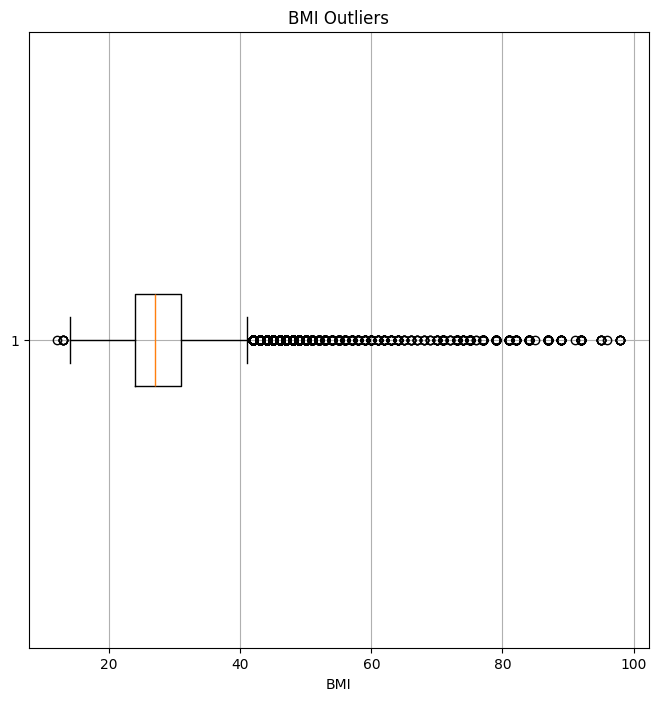

In [67]:
# outlier detection - primarily relevant for continuouos variables (BMI in this case)
# the purpose for this is to identify extreme observations that could distort models
# outliers can distort scaling and model fitting
plt.figure(figsize=(8,8))
plt.boxplot(X_train["BMI"], vert=False)
plt.title("BMI Outliers")
plt.xlabel("BMI")
plt.grid(True)
plt.show()

In [68]:
# using interquartile range to filter outliers in the visual above
Q1 = X_train["BMI"].quantile(0.25)
Q3 = X_train["BMI"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# I clipped the rows to avoid data loss
X_train["BMI"] = X_train["BMI"].clip(lower_bound, upper_bound)
X_test["BMI"] = X_test["BMI"].clip(lower_bound, upper_bound)

##### Feature Scaling

In [69]:
numeric_columns = [
    "BMI",
    "MentHlth",
    "PhysHlth",
    "Age",
    "Education",
    "Income",
    "Diabetes"
]

binary_columns = [
    "HighBP",
    "HighChol",
    "CholCheck",
    "Smoker",
    "Stroke",
    "PhysActivity",
    "HvyAlcoholConsump",
    "Sex"
]

preprocessor = ColumnTransformer(
    transformers=[("num", StandardScaler(), numeric_columns),
    ("bin", "passthrough", binary_columns) 
])

X_train_scaled = preprocessor.fit_transform(X_train)
X_test_scaled = preprocessor.transform(X_test)

##### Data Augmentation

Counter({0: 117833, 1: 12155})
balanced after augmentation
Counter({0: 82486, 1: 82486})


/Users/leesangoroh/Documents/GitHub/AIFoundations/.venv/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


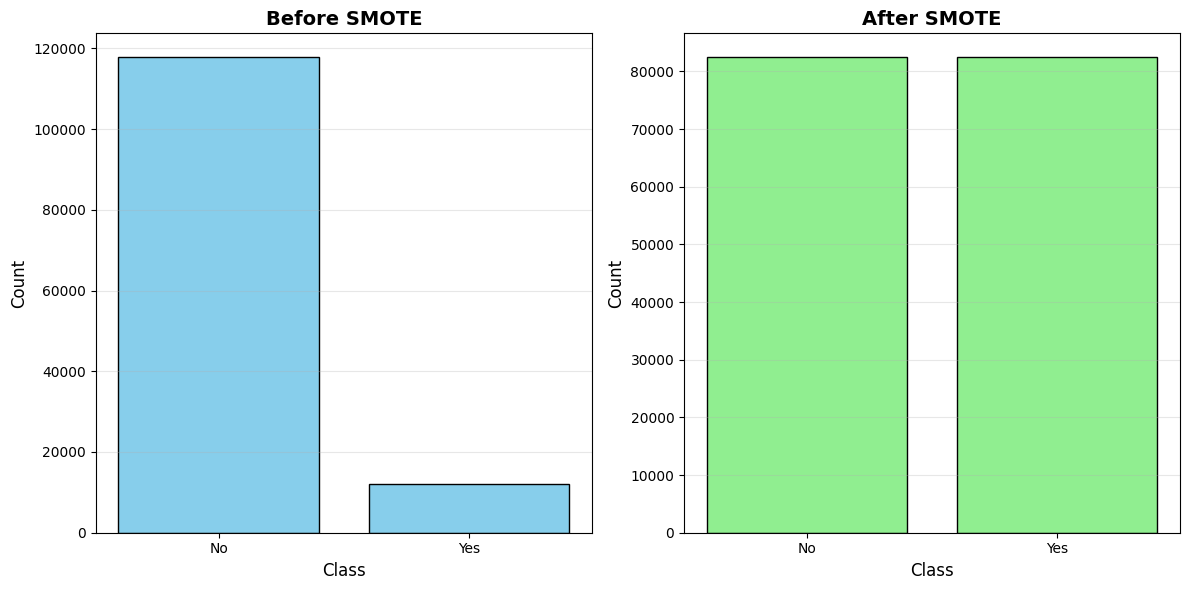

In [70]:
count = Counter(y)
print(count)
oversample = SMOTE()
X_train_sm, Y_train_sm = oversample.fit_resample(X_train_scaled, Y_train)
print("balanced after augmentation")
print(Counter(Y_train_sm))

# Data distribution before SMOTE
count_before = count
# Data distribution after SMOTE
count_after = Counter(Y_train_sm)

# Plotting the distributions
fig, ax = plt.subplots(1, 2, figsize=(12, 6))

# Before SMOTE
ax[0].bar(count_before.keys(), count_before.values(), color='skyblue', edgecolor='black')
ax[0].set_title("Before SMOTE", fontsize=14, fontweight='bold')
ax[0].set_xlabel("Class", fontsize=12)
ax[0].set_ylabel("Count", fontsize=12)
ax[0].set_xticks([0, 1])
ax[0].set_xticklabels(['No', 'Yes'])
ax[0].grid(axis='y', alpha=0.3)

# After SMOTE
ax[1].bar(count_after.keys(), count_after.values(), color='lightgreen', edgecolor='black')
ax[1].set_title("After SMOTE", fontsize=14, fontweight='bold')
ax[1].set_xlabel("Class", fontsize=12)
ax[1].set_ylabel("Count", fontsize=12)
ax[1].set_xticks([0, 1])
ax[1].set_xticklabels(['No', 'Yes'])
ax[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

##### Model Selection

1. Logistic Regression
2. K-Nearest Neighbours
3. Decision Tree
4. Random Forest
5. ANN (MLP)
6. Hist Gradient Boosting Classifier

1. Logistic Regression

In [71]:
# model training - LR
lr = LogisticRegression()
lr.fit(X_train_scaled, Y_train)


/Users/leesangoroh/Documents/GitHub/AIFoundations/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/leesangoroh/Documents/GitHub/AIFoundations/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/leesangoroh/Documents/GitHub/AIFoundations/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/leesangoroh/Documents/GitHub/AIFoundations/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/Users/leesangoroh/Documents/GitHub/AIFoundations/.venv/lib/python3.9/site-packages/sklearn

LogisticRegression()

In [72]:
ylrpredicted = lr.predict(X_test_scaled)
cm_lr = confusion_matrix(y_test, ylrpredicted)
print(cm_lr)

[[35042   305]
 [ 3289   361]]


/Users/leesangoroh/Documents/GitHub/AIFoundations/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/leesangoroh/Documents/GitHub/AIFoundations/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/leesangoroh/Documents/GitHub/AIFoundations/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


<Axes: >

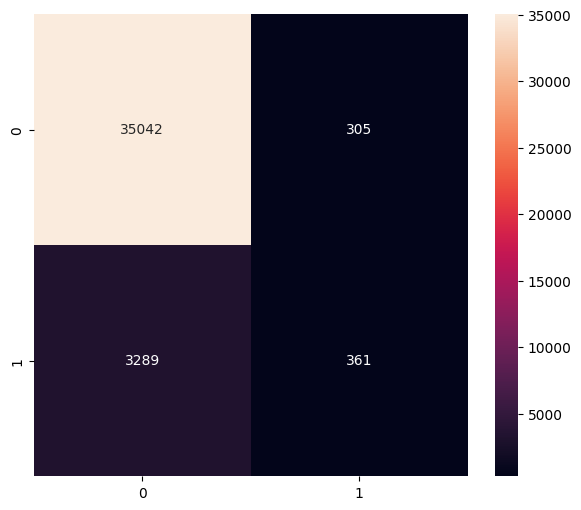

In [73]:
plt.figure(figsize=(7,6))
sb.heatmap(cm_lr, annot=True, fmt='d')

2. K-Nearest Neighbours

In [74]:
KNN = KNeighborsClassifier(n_neighbors=2)
KNN.fit(X_train_sm, Y_train_sm)

KNeighborsClassifier(n_neighbors=2)

In [75]:
yknnpredicted = KNN.predict(X_test_scaled)
knn_cm = confusion_matrix(y_test, yknnpredicted)
print(knn_cm)

[[32077  3270]
 [ 2627  1023]]


<Axes: >

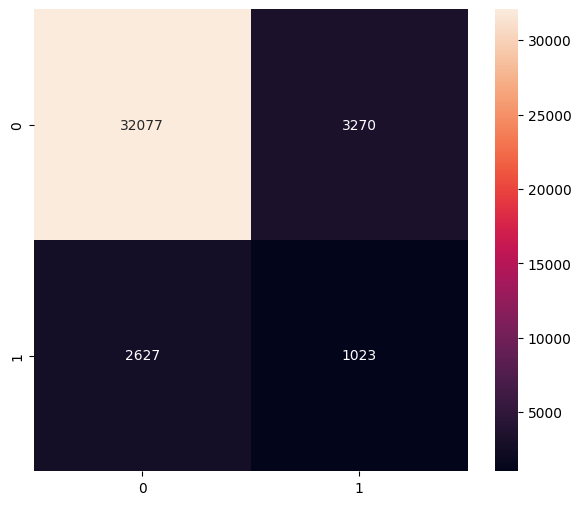

In [76]:
plt.figure(figsize=(7,6))
sb.heatmap(knn_cm, annot=True, fmt='d')

3. Decision Tree

In [77]:
# question - how does max_depth and entropy affect how a model trains
dt = DecisionTreeClassifier()
dt.fit(X_train_sm, Y_train_sm)

DecisionTreeClassifier()

In [78]:
ydtpredicted = dt.predict(X_test_scaled)
dt_cm = confusion_matrix(y_test, ydtpredicted)
print(dt_cm)

[[32245  3102]
 [ 2687   963]]


<Axes: >

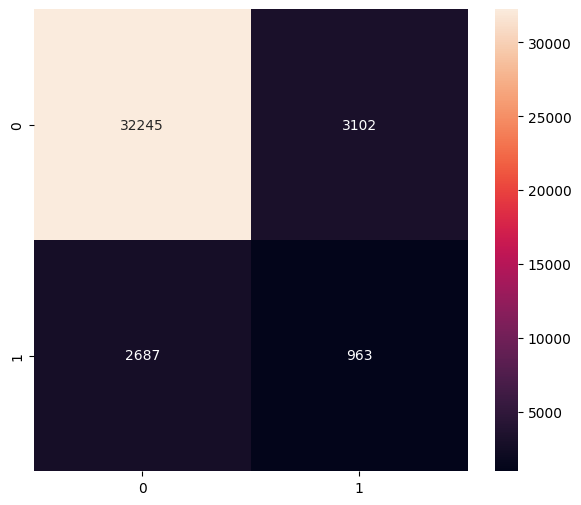

In [79]:
plt.figure(figsize=(7,6))
sb.heatmap(dt_cm, annot=True, fmt='d')

4. Random Forest

In [80]:
rf = RandomForestClassifier()
rf.fit(X_train_sm, Y_train_sm)

RandomForestClassifier()

In [81]:
yrfpredicted = rf.predict(X_test_scaled)
print(yrfpredicted)
rf_cm = confusion_matrix(y_test, yrfpredicted)
print(rf_cm)

[0 0 0 ... 0 0 0]
[[33932  1415]
 [ 2943   707]]


<Axes: >

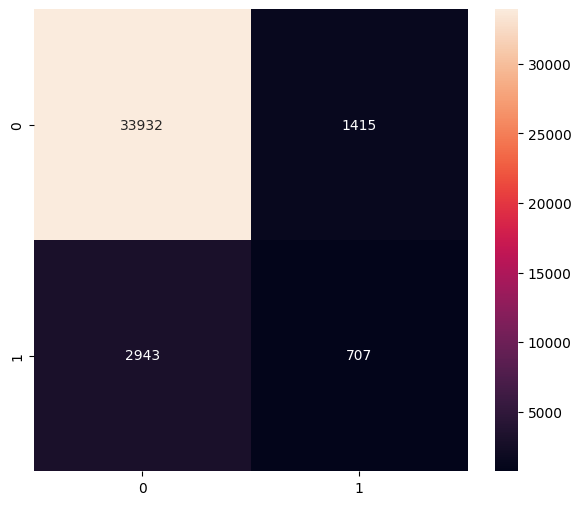

In [82]:
plt.figure(figsize=(7,6))
sb.heatmap(rf_cm, annot=True, fmt='d')

5. ANN

| Approach        | Effect                         |
| --------------- | ------------------------------ |
| No augmentation | Higher precision, lower recall |
| SMOTE           | Higher recall, lower precision |
| Class weighting | Often balanced performance     |


A Multi-Layer Perceptron classifier was implemented using three hidden layers with 64, 32, and 16 neurons respectively. ReLU activation and the Adam optimiser were used, while early stopping and L2 regularisation were applied to reduce overfitting and improve generalisation.

Interestingly, using augmented data to train the model reduced its precision

Adding an additional layer also increased the precision of the model

Due to the imbalance in the dataset, SMOTE was applied to generate additional synthetic samples for the minority class. This allowed the neural network to learn patterns associated with heart disease cases more effectively. However, while recall improved, precision decreased due to an increased number of false positives.

In [83]:
mlp = MLPClassifier(
    hidden_layer_sizes=(64, 32, 16),   # two hidden layers
    activation='relu',
    solver='adam',
    alpha=0.0001,                  # L2 regularization
    batch_size=32,
    learning_rate='adaptive',
    learning_rate_init=0.001,
    max_iter=500,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=10,
    random_state=42,
    verbose=False
)
mlp.fit(X_train_scaled, Y_train)

ymlp_pred = mlp.predict(X_test_scaled)
ymlp_prob = mlp.predict_proba(X_test_scaled)[:, 1]

print('Accuracy  : {:.4f}'.format(accuracy_score(y_test, ymlp_pred)))
print('F1-score  : {:.4f}'.format(f1_score(y_test, ymlp_pred)))
print('Precision : {:.4f}'.format(precision_score(y_test, ymlp_pred)))
print('Recall    : {:.4f}'.format(recall_score(y_test, ymlp_pred)))
print('ROC-AUC   : {:.4f}'.format(roc_auc_score(y_test, ymlp_prob)))
print('Final loss: {:.4f}'.format(mlp.loss_))

print("\nClassification Report:")
print(classification_report(y_test, ymlp_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, ymlp_pred))

/Users/leesangoroh/Documents/GitHub/AIFoundations/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/leesangoroh/Documents/GitHub/AIFoundations/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/leesangoroh/Documents/GitHub/AIFoundations/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/leesangoroh/Documents/GitHub/AIFoundations/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/leesangoroh/Documents/GitHub/AIFoundations/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/leesangoroh/Documents/GitHub/AIFoundations/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py

Accuracy  : 0.9084
F1-score  : 0.0929
Precision : 0.6310
Recall    : 0.0501
ROC-AUC   : 0.8378
Final loss: 0.2409

Classification Report:
              precision    recall  f1-score   support

           0       0.91      1.00      0.95     35347
           1       0.63      0.05      0.09      3650

    accuracy                           0.91     38997
   macro avg       0.77      0.52      0.52     38997
weighted avg       0.88      0.91      0.87     38997


Confusion Matrix:
[[35240   107]
 [ 3467   183]]


/Users/leesangoroh/Documents/GitHub/AIFoundations/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/leesangoroh/Documents/GitHub/AIFoundations/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/leesangoroh/Documents/GitHub/AIFoundations/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/leesangoroh/Documents/GitHub/AIFoundations/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/leesangoroh/Documents/GitHub/AIFoundations/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/leesangoroh/Documents/GitHub/AIFoundations/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py

Loss Curve for the MLP

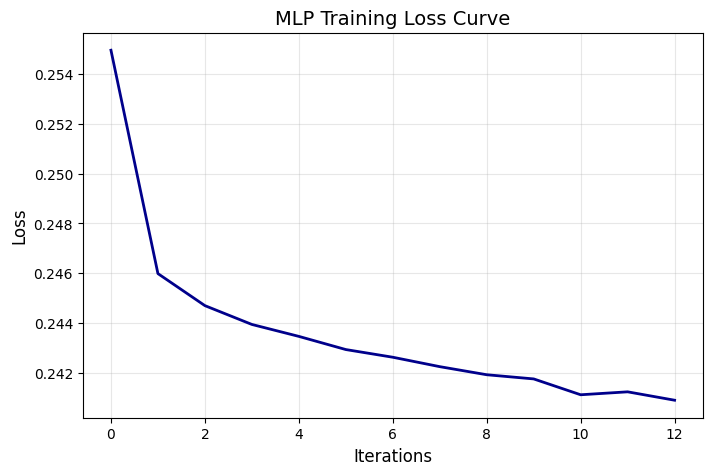

In [84]:
plt.figure(figsize=(8,5))

plt.plot(mlp.loss_curve_, color='darkblue', linewidth=2)

plt.title("MLP Training Loss Curve", fontsize=14)
plt.xlabel("Iterations", fontsize=12)
plt.ylabel("Loss", fontsize=12)

plt.grid(True, alpha=0.3)

plt.show()

ROC curve

/Users/leesangoroh/Documents/GitHub/AIFoundations/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/leesangoroh/Documents/GitHub/AIFoundations/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/leesangoroh/Documents/GitHub/AIFoundations/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


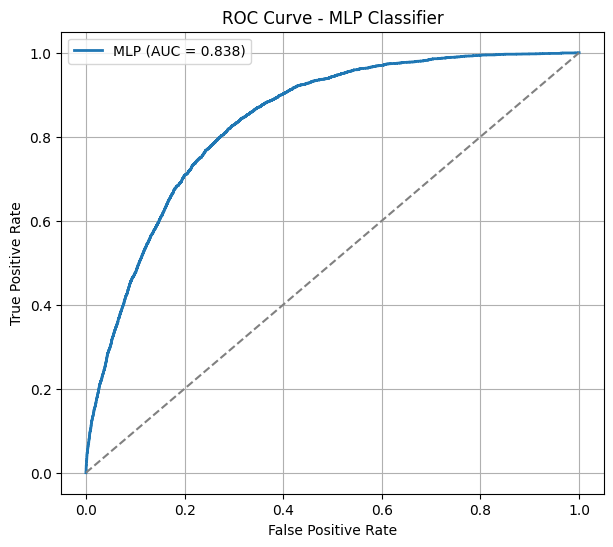

In [85]:
from sklearn.metrics import roc_curve, roc_auc_score

y_prob = mlp.predict_proba(X_test_scaled)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc_score = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(7,6))

plt.plot(fpr, tpr, label=f"MLP (AUC = {auc_score:.3f})", linewidth=2)
plt.plot([0,1], [0,1], linestyle="--", color="gray")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - MLP Classifier")

plt.legend()
plt.grid(True)

plt.show()

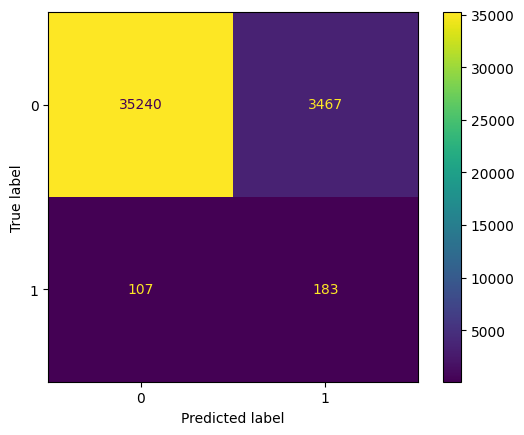

In [86]:
cfm_mlp = confusion_matrix(ymlp_pred, y_test)
ConfusionMatrixDisplay(cfm_mlp).plot()

Hist Gradient Boosting Classifier

In [87]:
hgb = HistGradientBoostingClassifier(
    max_iter=200,
    learning_rate=0.05,
    max_depth=6,
    random_state=42
)

hgb.fit(X_train_sm, Y_train_sm)

y_hgb_pred = hgb.predict(X_test_scaled)
y_hgb_prob = hgb.predict_proba(X_test_scaled)[:, 1]

print("Accuracy  : {:.4f}".format(accuracy_score(y_test, y_hgb_pred)))
print("Precision : {:.4f}".format(precision_score(y_test, y_hgb_pred)))
print("Recall    : {:.4f}".format(recall_score(y_test, y_hgb_pred)))
print("F1-score  : {:.4f}".format(f1_score(y_test, y_hgb_pred)))
print("ROC-AUC   : {:.4f}".format(roc_auc_score(y_test, y_hgb_prob)))

print("\nClassification Report:")
print(classification_report(y_test, y_hgb_pred))


y_hgb_pred_03 = (y_hgb_prob >= 0.3).astype(int)

print("Accuracy  :", accuracy_score(y_test, y_hgb_pred_03))
print("Precision :", precision_score(y_test, y_hgb_pred_03))
print("Recall    :", recall_score(y_test, y_hgb_pred_03))
print("F1-score  :", f1_score(y_test, y_hgb_pred_03))

Accuracy  : 0.8859
Precision : 0.3706
Recall    : 0.3134
F1-score  : 0.3396
ROC-AUC   : 0.8310

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.95      0.94     35347
           1       0.37      0.31      0.34      3650

    accuracy                           0.89     38997
   macro avg       0.65      0.63      0.64     38997
weighted avg       0.88      0.89      0.88     38997

Accuracy  : 0.8073954406749237
Precision : 0.2738666979032447
Recall    : 0.6405479452054794
F1-score  : 0.3836875358989087


##### Models Comparison

In [ ]:
# helper function-calculates specificity
def calculate_specificity(cm):
    tn, fp, fn, tp = cm.ravel()
    return tn / (tn + fp)

def modelPerformance(model, y_test, ypredicted, y_prob=None):
    
    report = classification_report(y_test, ypredicted, output_dict=True, zero_division=0)
    print(classification_report(y_test, ypredicted, zero_division=0))

    # Original confusion matrix
    cm = confusion_matrix(y_test, ypredicted)

    reordered_cm = np.array([
        [cm[1,1], cm[1,0]],  # TP, FN
        [cm[0,1], cm[0,0]]   # FP, TN
    ])

    # Overall metrics (use original cm)
    f_one_score = f1_score(y_test, ypredicted, zero_division=0)
    accuracy = accuracy_score(y_test, ypredicted)
    recall = recall_score(y_test, ypredicted, zero_division=0)
    precision = precision_score(y_test, ypredicted, zero_division=0)
    specificity = calculate_specificity(cm)

    # AUC
    if y_prob is not None:
        auc = roc_auc_score(y_test, y_prob)
    else:
        auc = roc_auc_score(y_test, ypredicted)

    # Labels in new order
    labels = np.array([
        ["TP", "FN"],
        ["FP", "TN"]
    ])

    annot = np.empty_like(reordered_cm).astype(str)

    for i in range(reordered_cm.shape[0]):
        for j in range(reordered_cm.shape[1]):
            annot[i, j] = f"{labels[i, j]}\n{reordered_cm[i, j]}"

    plt.figure(figsize=(6, 5))
    sb.heatmap(
        reordered_cm,
        annot=annot,
        fmt='',
        cmap='Blues',
        cbar=False,
        xticklabels=["Predicted Heart Disease (1)", "Predicted No Disease (0)"],
        yticklabels=["Actual Heart Disease (1)", "Actual No Disease (0)"]
    )

    plt.title(f"Confusion Matrix - {model}", fontsize=12, fontweight="bold")
    plt.ylabel("Actual Class", fontsize=11)
    plt.xlabel("Predicted Class", fontsize=11)
    plt.tight_layout()
    plt.show()

    return {
        "model": model,
        "f1_score": f_one_score,
        "accuracy": accuracy,
        "recall": recall,
        "precision": precision,
        "specificity": specificity,
        "auc": auc,

        # class 0 metrics
        "Model": model,
        "class_0_precision": report["0"]["precision"],
        "class_0_recall": report["0"]["recall"],
        "class_0_f1": report["0"]["f1-score"],
        "class_0_support": report["0"]["support"],

        # class 1 metrics
        "Model Name": model,
        "class_1_precision": report["1"]["precision"],
        "class_1_recall": report["1"]["recall"],
        "class_1_f1": report["1"]["f1-score"],
        "class_1_support": report["1"]["support"],
    }


              precision    recall  f1-score   support

           0       0.91      0.99      0.95     35347
           1       0.54      0.10      0.17      3650

    accuracy                           0.91     38997
   macro avg       0.73      0.55      0.56     38997
weighted avg       0.88      0.91      0.88     38997



/Users/leesangoroh/Documents/GitHub/AIFoundations/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/leesangoroh/Documents/GitHub/AIFoundations/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/leesangoroh/Documents/GitHub/AIFoundations/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/leesangoroh/Documents/GitHub/AIFoundations/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/leesangoroh/Documents/GitHub/AIFoundations/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/leesangoroh/Documents/GitHub/AIFoundations/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py

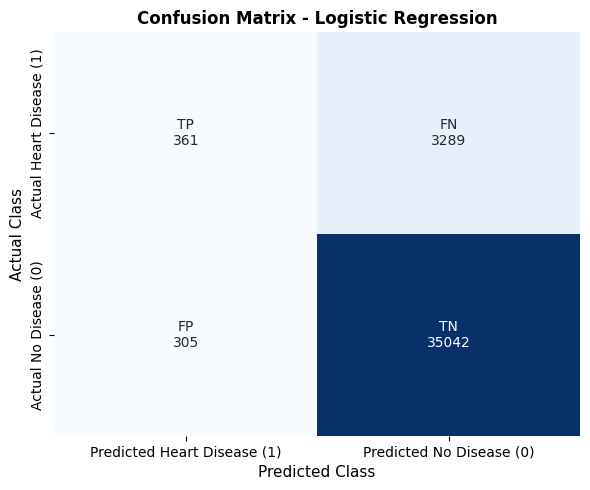

              precision    recall  f1-score   support

           0       0.92      0.91      0.92     35347
           1       0.24      0.28      0.26      3650

    accuracy                           0.85     38997
   macro avg       0.58      0.59      0.59     38997
weighted avg       0.86      0.85      0.85     38997



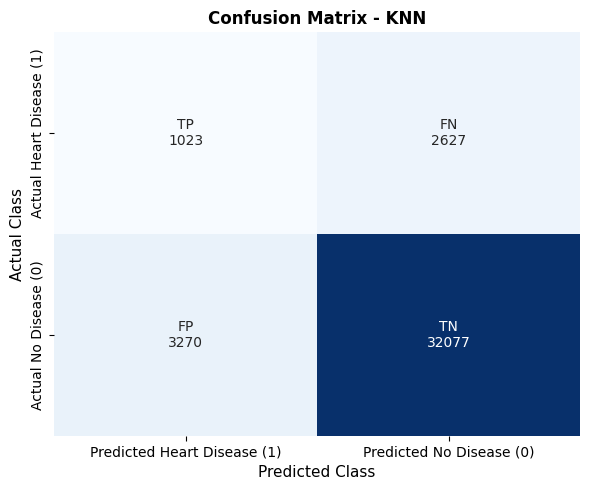

              precision    recall  f1-score   support

           0       0.92      0.79      0.85     35347
           1       0.14      0.34      0.20      3650

    accuracy                           0.75     38997
   macro avg       0.53      0.57      0.53     38997
weighted avg       0.85      0.75      0.79     38997



/Users/leesangoroh/Documents/GitHub/AIFoundations/.venv/lib/python3.9/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(
/Users/leesangoroh/Documents/GitHub/AIFoundations/.venv/lib/python3.9/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(


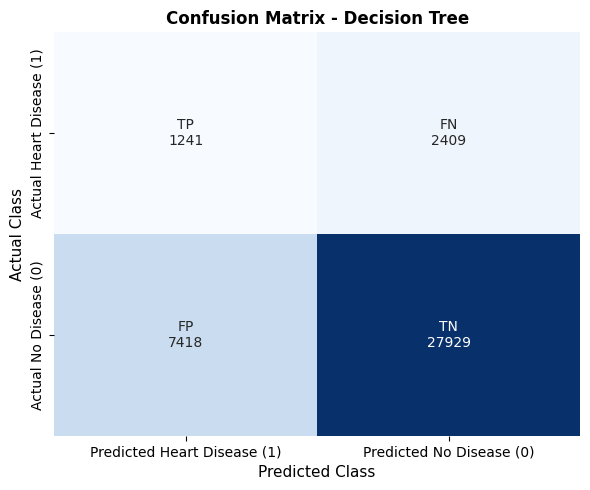

/Users/leesangoroh/Documents/GitHub/AIFoundations/.venv/lib/python3.9/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
/Users/leesangoroh/Documents/GitHub/AIFoundations/.venv/lib/python3.9/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


              precision    recall  f1-score   support

           0       0.90      0.91      0.91     35347
           1       0.08      0.07      0.07      3650

    accuracy                           0.83     38997
   macro avg       0.49      0.49      0.49     38997
weighted avg       0.83      0.83      0.83     38997



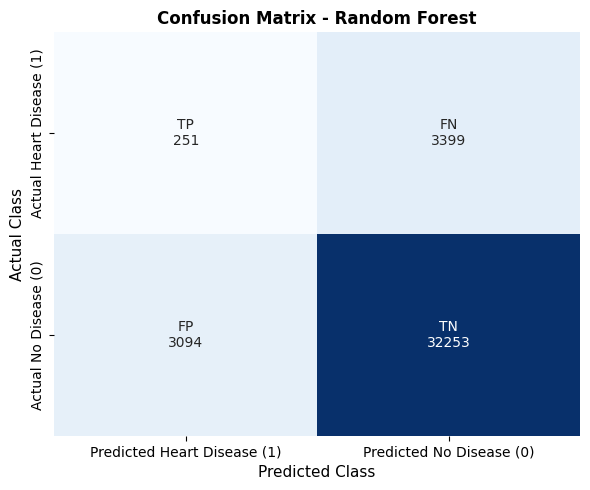

              precision    recall  f1-score   support

           0       0.91      1.00      0.95     35347
           1       0.63      0.05      0.09      3650

    accuracy                           0.91     38997
   macro avg       0.77      0.52      0.52     38997
weighted avg       0.88      0.91      0.87     38997



/Users/leesangoroh/Documents/GitHub/AIFoundations/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/leesangoroh/Documents/GitHub/AIFoundations/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/leesangoroh/Documents/GitHub/AIFoundations/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/leesangoroh/Documents/GitHub/AIFoundations/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/leesangoroh/Documents/GitHub/AIFoundations/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/leesangoroh/Documents/GitHub/AIFoundations/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py

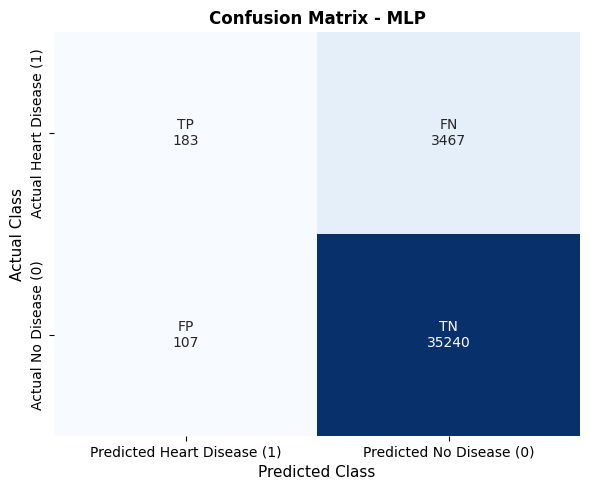

              precision    recall  f1-score   support

           0       0.96      0.82      0.89     35347
           1       0.27      0.64      0.38      3650

    accuracy                           0.81     38997
   macro avg       0.62      0.73      0.63     38997
weighted avg       0.89      0.81      0.84     38997



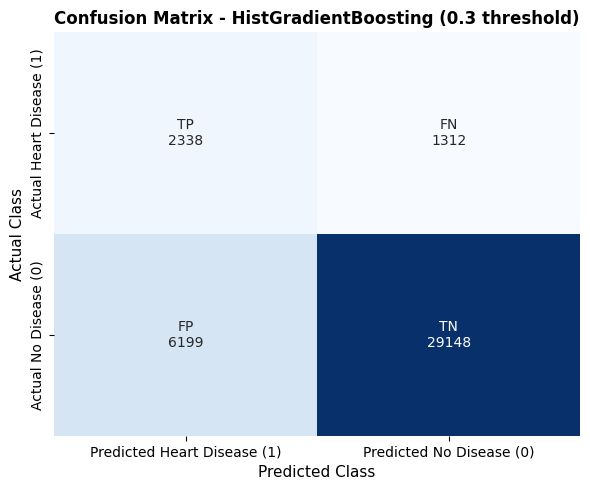

,model,f1_score,accuracy,recall,precision,specificity,auc,Model,class_0_precision,class_0_recall,class_0_f1,class_0_support,Model Name,class_1_precision,class_1_recall,class_1_f1,class_1_support
4,MLP,0.0929,0.9084,0.0501,0.6310,0.9970,0.8378,MLP,0.9104,0.9970,0.9517,35347.0,MLP,0.6310,0.0501,0.0929,3650.0
0,Logistic Regression,0.1673,0.9078,0.0989,0.5420,0.9914,0.8372,Logistic Regression,0.9142,0.9914,0.9512,35347.0,Logistic Regression,0.5420,0.0989,0.1673,3650.0
5,HistGradientBoosting (0.3 threshold),0.3837,0.8074,0.6405,0.2739,0.8246,0.8310,HistGradientBoosting (0.3 threshold),0.9569,0.8246,0.8859,35347.0,HistGradientBoosting (0.3 threshold),0.2739,0.6405,0.3837,3650.0
1,KNN,0.2576,0.8488,0.2803,0.2383,0.9075,0.6550,KNN,0.9243,0.9075,0.9158,35347.0,KNN,0.2383,0.2803,0.2576,3650.0
2,Decision Tree,0.2016,0.7480,0.3400,0.1433,0.7901,0.5651,Decision Tree,0.9206,0.7901,0.8504,35347.0,Decision Tree,0.1433,0.3400,0.2016,3650.0
3,Random Forest,0.0718,0.8335,0.0688,0.0750,0.9125,0.4959,Random Forest,0.9047,0.9125,0.9085,35347.0,Random Forest,0.0750,0.0688,0.0718,3650.0


In [89]:
# Logistic Regression
y_lr_pred = lr.predict(X_test_scaled)
y_lr_prob = lr.predict_proba(X_test_scaled)[:, 1]
lr_results = modelPerformance("Logistic Regression", y_test, y_lr_pred, y_lr_prob)

# KNN
y_knn_pred = KNN.predict(X_test_scaled)
y_knn_prob = KNN.predict_proba(X_test_scaled)[:, 1]
knn_results = modelPerformance("KNN", y_test, y_knn_pred, y_knn_prob)

# Decision Tree
y_dt_pred = dt.predict(X_test)
y_dt_prob = dt.predict_proba(X_test)[:, 1]
dt_results = modelPerformance("Decision Tree", y_test, y_dt_pred, y_dt_prob)

# Random Forest
y_rf_pred = rf.predict(X_test)
y_rf_prob = rf.predict_proba(X_test)[:, 1]
rf_results = modelPerformance("Random Forest", y_test, y_rf_pred, y_rf_prob)

# MLP
y_mlp_pred = mlp.predict(X_test_scaled)
y_mlp_prob = mlp.predict_proba(X_test_scaled)[:, 1]
mlp_results = modelPerformance("MLP", y_test, y_mlp_pred, y_mlp_prob)

# HistGradientBoosting with threshold 0.3
y_hgb_prob = hgb.predict_proba(X_test_scaled)[:, 1]
y_hgb_pred_03 = (y_hgb_prob >= 0.3).astype(int)
hgb_results = modelPerformance("HistGradientBoosting (0.3 threshold)", y_test, y_hgb_pred_03, y_hgb_prob)

# Combine results
all_results = [
    lr_results,
    knn_results,
    dt_results,
    rf_results,
    mlp_results,
    hgb_results
]

results_df = pd.DataFrame(all_results).round(4)
results_df.sort_values(by="auc", ascending=False)

Figure below shows a comparison of classification performance metrics across the evaluated models. HistGradientBoosting achieved the best balance between recall and F1-score.

<Figure size 1500x600 with 0 Axes>

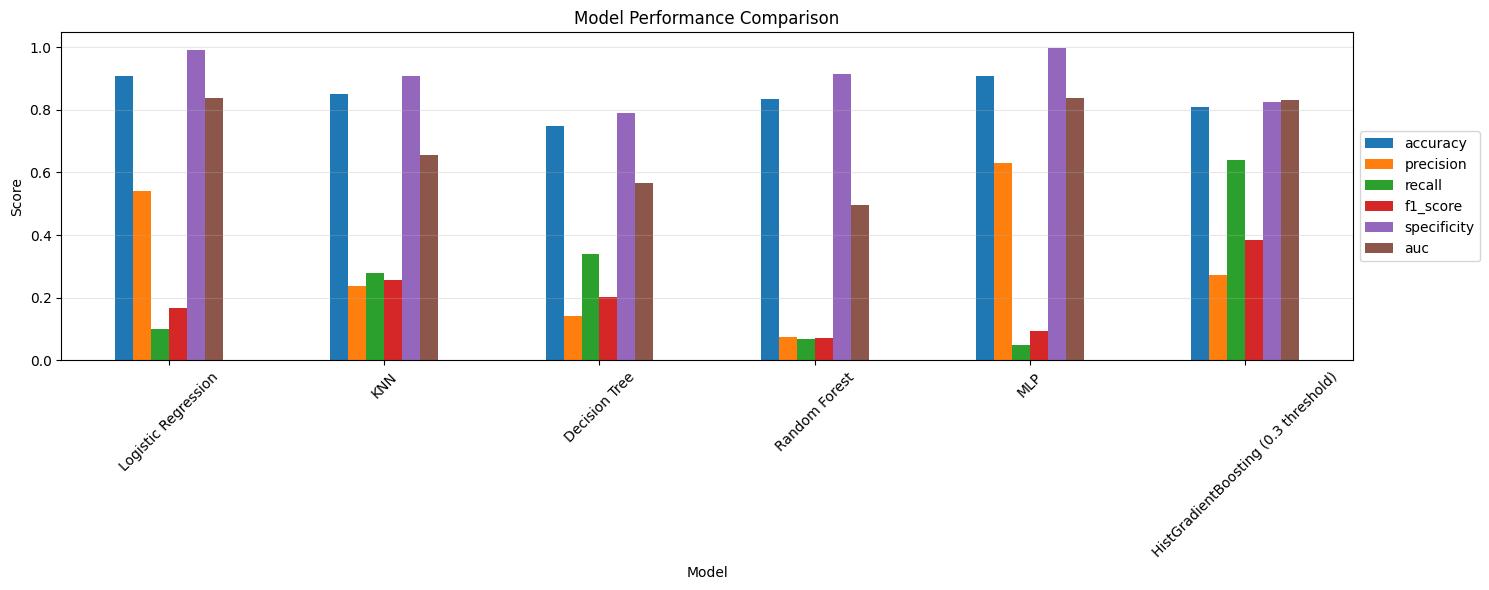

In [90]:
# visualizing models performance
plt.figure(figsize=(15,6))

metrics = ["accuracy", "precision", "recall", "f1_score", "specificity", "auc"]

results_df.set_index("model")[metrics].plot(
    kind="bar",
    figsize=(15,6)
)

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xlabel("Model")
plt.xticks(rotation=45)
plt.legend(
    loc='center left',
    bbox_to_anchor=(1, 0.5)
)
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

Figure below shows the ROC curves for all models. The area under the curve (AUC) indicates the model's ability to distinguish between classes, with higher values representing better discriminative performance.

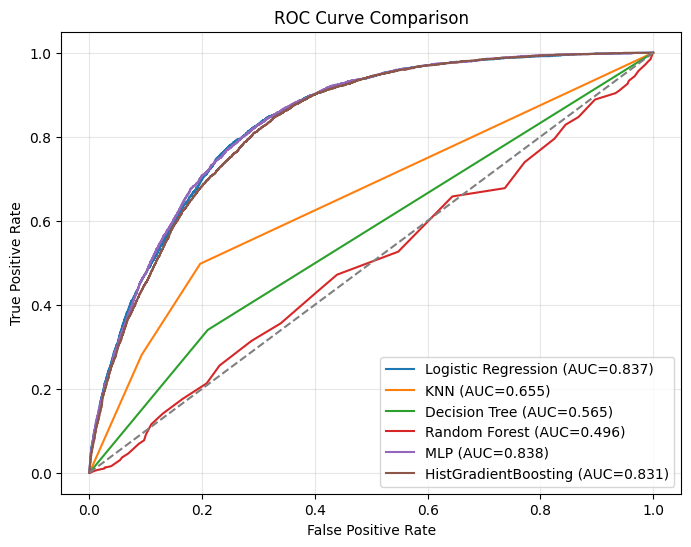

In [91]:
# roc curve comparison
from sklearn.metrics import roc_curve, roc_auc_score

plt.figure(figsize=(8,6))

models = {
    "Logistic Regression": (y_lr_prob),
    "KNN": (y_knn_prob),
    "Decision Tree": (y_dt_prob),
    "Random Forest": (y_rf_prob),
    "MLP": (y_mlp_prob),
    "HistGradientBoosting": (y_hgb_prob)
}

for name, probs in models.items():
    
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc = roc_auc_score(y_test, probs)

    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")

plt.plot([0,1],[0,1],'--',color='gray')

plt.title("ROC Curve Comparison")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

##### Improve Performance - Hist Gradient Boosting Classifier

1. Threshold Optimization

In [92]:
precision, recall, thresholds = precision_recall_curve(y_test, y_hgb_prob)

# avoid division by zero and align with thresholds
f1_scores = 2 * precision[:-1] * recall[:-1] / (precision[:-1] + recall[:-1] + 1e-10)

best_index = np.argmax(f1_scores)
best_threshold = thresholds[best_index]

print("Best threshold:", best_threshold)
print("Best F1 from curve:", f1_scores[best_index])

y_hgb_pred_opt = (y_hgb_prob >= best_threshold).astype(int)

Best threshold: 0.33498761347455935
Best F1 from curve: 0.38767720824356044


              precision    recall  f1-score   support

           0       0.95      0.85      0.90     35347
           1       0.29      0.58      0.39      3650

    accuracy                           0.83     38997
   macro avg       0.62      0.72      0.64     38997
weighted avg       0.89      0.83      0.85     38997



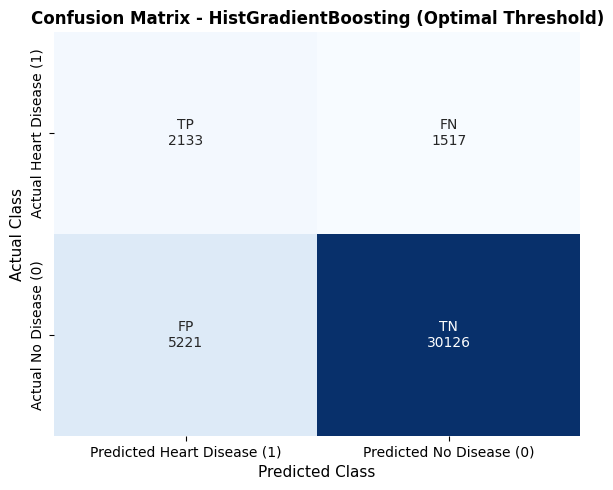

In [93]:
opt_results = modelPerformance(
    "HistGradientBoosting (Optimal Threshold)",
    y_test,
    y_hgb_pred_opt,
    y_hgb_prob
)

In [94]:
# Combine results
all_results = [
   opt_results,
    hgb_results
]

results_df = pd.DataFrame(all_results).round(4)
results_df.sort_values(by="f1_score", ascending=False)

,model,f1_score,accuracy,recall,precision,specificity,auc,Model,class_0_precision,class_0_recall,class_0_f1,class_0_support,Model Name,class_1_precision,class_1_recall,class_1_f1,class_1_support
0,HistGradientBoosting (Optimal Threshold),0.3877,0.8272,0.5844,0.2900,0.8523,0.831,HistGradientBoosting (Optimal Threshold),0.9521,0.8523,0.8994,35347.0,HistGradientBoosting (Optimal Threshold),0.2900,0.5844,0.3877,3650.0
1,HistGradientBoosting (0.3 threshold),0.3837,0.8074,0.6405,0.2739,0.8246,0.831,HistGradientBoosting (0.3 threshold),0.9569,0.8246,0.8859,35347.0,HistGradientBoosting (0.3 threshold),0.2739,0.6405,0.3837,3650.0


In [95]:
thresholds = [0.25, 0.30, 0.35]

for t in thresholds:
    y_pred = (y_hgb_prob >= t).astype(int)
    print("\nThreshold:", t)
    print("Recall:", recall_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred))
    print("F1:", f1_score(y_test, y_pred))


Threshold: 0.25
Recall: 0.7104109589041095
Precision: 0.24918316355948492
F1: 0.36895276038702335

Threshold: 0.3
Recall: 0.6405479452054794
Precision: 0.2738666979032447
F1: 0.3836875358989087

Threshold: 0.35
Recall: 0.5547945205479452
Precision: 0.2930535455861071
F1: 0.3835227272727273


              precision    recall  f1-score   support

           0       0.96      0.78      0.86     35347
           1       0.25      0.71      0.37      3650

    accuracy                           0.77     38997
   macro avg       0.61      0.74      0.62     38997
weighted avg       0.90      0.77      0.82     38997



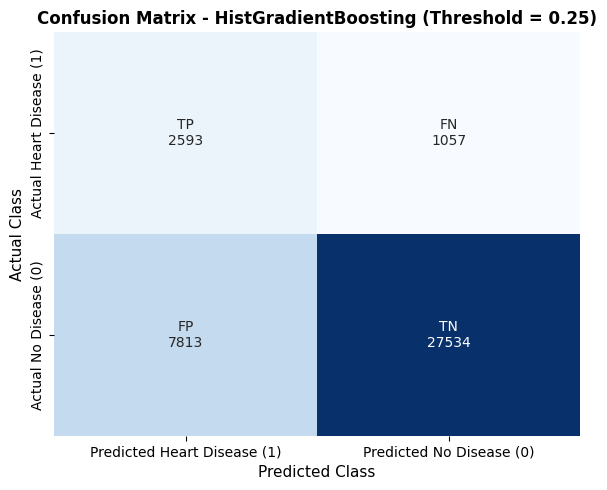

In [96]:
y_hgb_pred_025 = (y_hgb_prob >= 0.25).astype(int)
t025_results = modelPerformance(
    "HistGradientBoosting (Threshold = 0.25)",
    y_test,
    y_hgb_pred_025,
    y_hgb_prob
)

Figure below illustrates how precision and recall vary as the classification threshold changes. The figure shows that lowering the threshold increases recall but simultaneously decreases precision. 

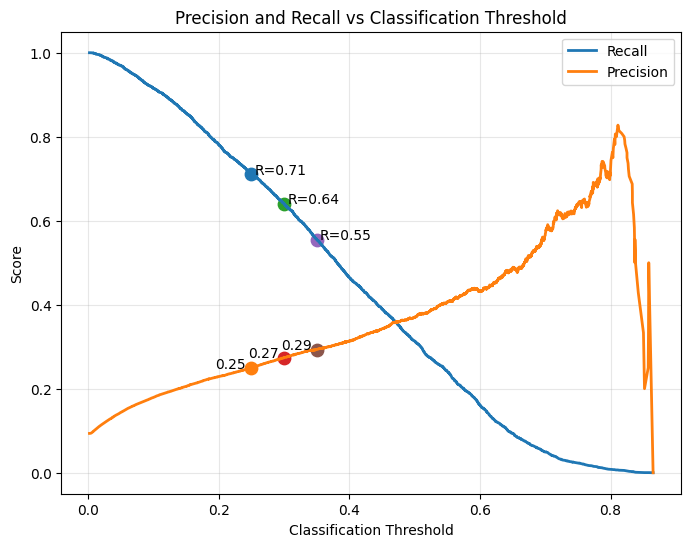

In [97]:
# precision-recall curve visualization

precision, recall, thresholds = precision_recall_curve(y_test, y_hgb_prob)

plt.figure(figsize=(8,6))

plt.plot(thresholds, recall[:-1], label="Recall", linewidth=2)
plt.plot(thresholds, precision[:-1], label="Precision", linewidth=2)

thresholds_to_mark = [0.25, 0.30, 0.35]

for t in thresholds_to_mark:
    y_pred = (y_hgb_prob >= t).astype(int)
    r = recall_score(y_test, y_pred)
    p = precision_score(y_test, y_pred)

    plt.scatter(t, r, s=80)
    plt.scatter(t, p, s=80)

    plt.text(t+0.005, r, f"R={r:.2f}")
    plt.text(t-0.055, p, f"{p:.2f}")

plt.xlabel("Classification Threshold")
plt.ylabel("Score")
plt.title("Precision and Recall vs Classification Threshold")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

Figure below presents the precision–recall curve, which further highlights the trade-off between detecting positive cases and maintaining reliable predictions. Based on these results, a threshold of 0.25 was selected as it provides the best balance between maximizing recall and maintaining acceptable precision. This adjustment improved the model’s ability to detect heart disease cases compared to the original threshold configuration.

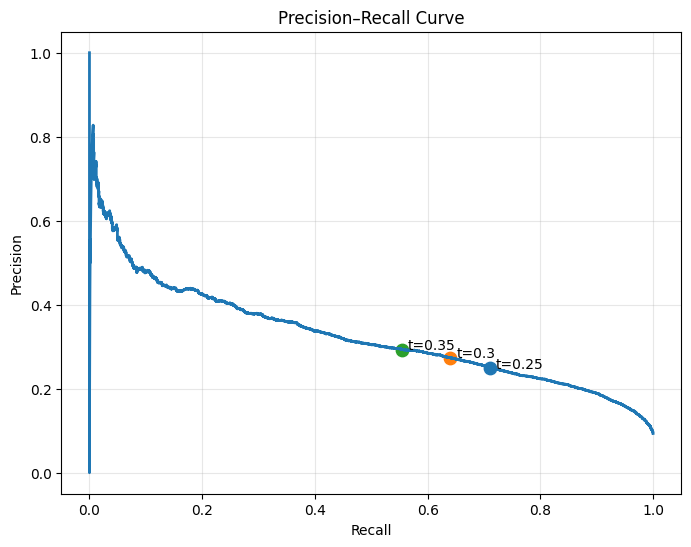

In [98]:
precision, recall, thresholds = precision_recall_curve(y_test, y_hgb_prob)

plt.figure(figsize=(8,6))

plt.plot(recall, precision, linewidth=2)

for t in [0.25,0.30,0.35]:
    y_pred = (y_hgb_prob >= t).astype(int)
    r = recall_score(y_test, y_pred)
    p = precision_score(y_test, y_pred)

    plt.scatter(r, p, s=80)
    plt.text(r+0.01, p, f"t={t}")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve")
plt.grid(alpha=0.3)

plt.show()

2. Cost-sensitive learning through sample weights

In [99]:
# higher weight for positive class
sample_weights = np.where(Y_train_sm == 1, 2.0, 1.0)

hgb_weighted = HistGradientBoostingClassifier(
    max_iter=200,
    learning_rate=0.05,
    max_depth=6,
    random_state=42
)

hgb_weighted.fit(X_train_sm, Y_train_sm, sample_weight=sample_weights)

y_hgb_weighted_prob = hgb_weighted.predict_proba(X_test_scaled)[:, 1]
y_hgb_weighted_pred = (y_hgb_weighted_prob >= 0.25).astype(int)

              precision    recall  f1-score   support

           0       0.98      0.67      0.80     35347
           1       0.21      0.84      0.34      3650

    accuracy                           0.69     38997
   macro avg       0.59      0.76      0.57     38997
weighted avg       0.90      0.69      0.75     38997



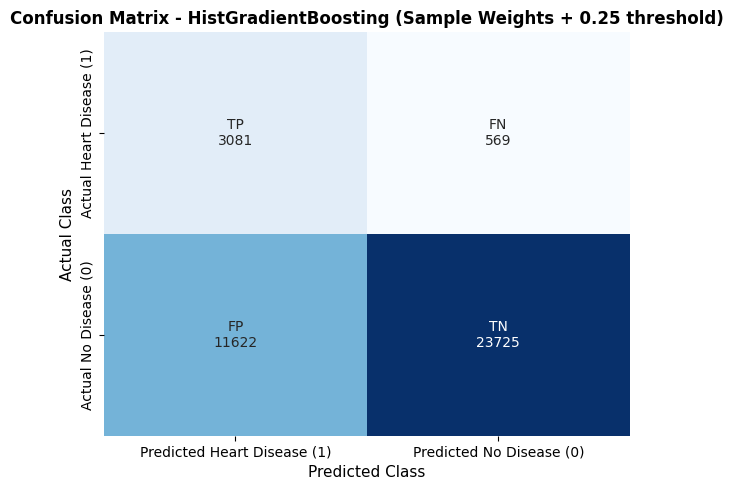

In [100]:
weighted_results = modelPerformance(
    "HistGradientBoosting (Sample Weights + 0.25 threshold)",
    y_test,
    y_hgb_weighted_pred,
    y_hgb_weighted_prob
)

In [103]:
# Combine results
all_results = [
   hgb_results,
    weighted_results
]

results_df = pd.DataFrame(all_results).round(4)
results_df.sort_values(by="auc", ascending=False)

,model,f1_score,accuracy,recall,precision,specificity,auc,Model,class_0_precision,class_0_recall,class_0_f1,class_0_support,Model Name,class_1_precision,class_1_recall,class_1_f1,class_1_support
1,HistGradientBoosting (Sample Weights + 0.25 th...,0.3357,0.6874,0.8441,0.2095,0.6712,0.832,HistGradientBoosting (Sample Weights + 0.25 th...,0.9766,0.6712,0.7956,35347.0,HistGradientBoosting (Sample Weights + 0.25 th...,0.2095,0.8441,0.3357,3650.0
0,HistGradientBoosting (0.3 threshold),0.3837,0.8074,0.6405,0.2739,0.8246,0.831,HistGradientBoosting (0.3 threshold),0.9569,0.8246,0.8859,35347.0,HistGradientBoosting (0.3 threshold),0.2739,0.6405,0.3837,3650.0


While threshold optimization produced the best balanced model performance, cost-sensitive learning achieved the highest recall and may be preferable in medical screening scenarios where detecting positive cases is critical.

In [104]:
# combined results - improvement methods(2) plus optimized threshold
all_results = [
    hgb_results,
    t025_results,
    weighted_results
]
results_df = pd.DataFrame(all_results).round(4)
results_df.sort_values(by="recall", ascending=False)

,model,f1_score,accuracy,recall,precision,specificity,auc,Model,class_0_precision,class_0_recall,class_0_f1,class_0_support,Model Name,class_1_precision,class_1_recall,class_1_f1,class_1_support
2,HistGradientBoosting (Sample Weights + 0.25 th...,0.3357,0.6874,0.8441,0.2095,0.6712,0.832,HistGradientBoosting (Sample Weights + 0.25 th...,0.9766,0.6712,0.7956,35347.0,HistGradientBoosting (Sample Weights + 0.25 th...,0.2095,0.8441,0.3357,3650.0
1,HistGradientBoosting (Threshold = 0.25),0.3690,0.7725,0.7104,0.2492,0.7790,0.831,HistGradientBoosting (Threshold = 0.25),0.9630,0.7790,0.8613,35347.0,HistGradientBoosting (Threshold = 0.25),0.2492,0.7104,0.3690,3650.0
0,HistGradientBoosting (0.3 threshold),0.3837,0.8074,0.6405,0.2739,0.8246,0.831,HistGradientBoosting (0.3 threshold),0.9569,0.8246,0.8859,35347.0,HistGradientBoosting (0.3 threshold),0.2739,0.6405,0.3837,3650.0
